In [1]:
pip install numpy scipy pandas matplotlib requests

Connecting to NASA CDAWeb API...
Requesting variables [BZ_GSM,flow_speed,Pressure,AE_INDEX,SYM_H] from NASA...

================ STORM PHYSICAL EXTREMA ================
Minimum SYM-H (Ring Current Peak): -518.0 nT at 2024-05-11 02:14:00+00:00 UT
Peak Auroral Electrojet (AE Index): 4098.0 nT
Peak Solar Wind Speed (Vsw):        1025.9 km/s
Minimum IMF Bz:                     -47.9 nT



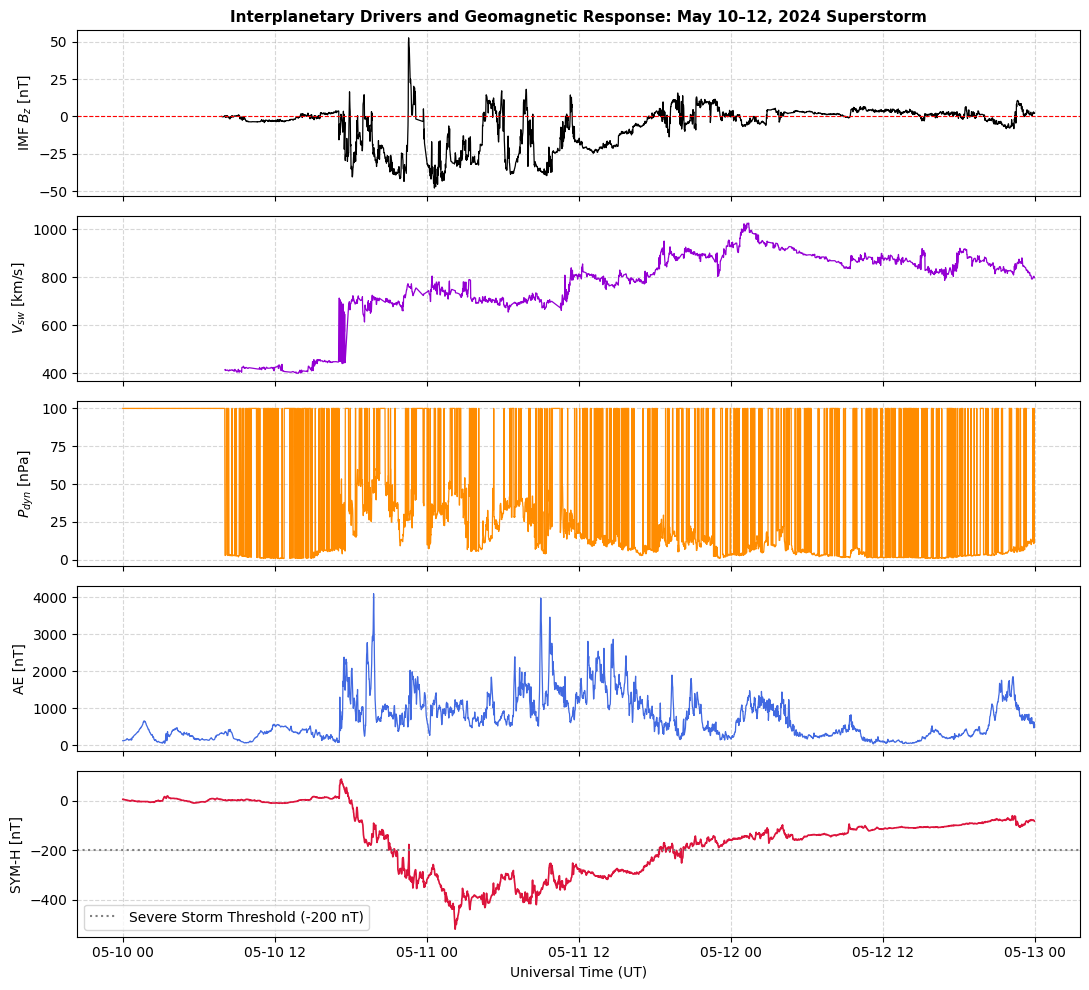

Saved: Figure_1_Storm_Overview.png and omni_drivers_may2024.csv


In [4]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

print("Connecting to NASA CDAWeb API...")

# 1. Query CDAWeb HAPI for May 10-12, 2024
start_time = "2024-05-10T00:00:00Z"
stop_time = "2024-05-12T23:59:00Z"
dataset_id = "OMNI_HRO_1MIN"

# Discover available variable names for this dataset
info_url = f"https://cdaweb.gsfc.nasa.gov/hapi/info?id={dataset_id}"
res_info = requests.get(info_url, timeout=20)

target_params = []
if res_info.status_code == 200:
    all_params = [p["name"] for p in res_info.json().get("parameters", [])]
    # Map desired physical quantities to exact CDAWeb variable names
    candidates = {
        "Bz": ["BZ_GSM", "BZ_GSE"],
        "Vsw": ["flow_speed", "V"],
        "Pdyn": ["Pressure", "flow_pressure", "Pressure_ratio"],
        "AE": ["AE_INDEX", "AE"],
        "SYMH": ["SYM_H"],
    }
    for key, opts in candidates.items():
        for opt in opts:
            if opt in all_params:
                target_params.append(opt)
                break
else:
    # Fallback to standard OMNI CDF names
    target_params = ["BZ_GSM", "flow_speed", "Pressure", "AE_INDEX", "SYM_H"]

param_str = ",".join(target_params)
data_url = f"https://cdaweb.gsfc.nasa.gov/hapi/data?id={dataset_id}&time.min={start_time}&time.max={stop_time}&parameters={param_str}"

print(f"Requesting variables [{param_str}] from NASA...")
headers = {"User-Agent": "SpacePhysicsResearch/1.0"}
res_data = requests.get(data_url, headers=headers, timeout=30)
res_data.raise_for_status()

# 2. Parse CSV stream into pandas DataFrame
col_names = ["Timestamp"] + target_params
df = pd.read_csv(
    io.StringIO(res_data.text), names=col_names, header=None, low_memory=False
)

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df.set_index("Timestamp", inplace=True)

# Clean fill values (standard space physics flags: > 9000 or < -9000)
for col in target_params:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].apply(lambda x: np.nan if (x > 9000 or x < -9000) else x)

df.interpolate(method="time", inplace=True)

# Standardize column naming for plotting
rename_map = {}
for col in df.columns:
    if "BZ" in col:
        rename_map[col] = "Bz"
    elif "speed" in col.lower() or col == "V":
        rename_map[col] = "Vsw"
    elif "pressure" in col.lower():
        rename_map[col] = "Pdyn"
    elif "AE" in col:
        rename_map[col] = "AE"
    elif "SYM_H" in col:
        rename_map[col] = "SYMH"

df.rename(columns=rename_map, inplace=True)

# 3. Print Storm Physical Extrema
min_symh = df["SYMH"].min()
min_symh_time = df["SYMH"].idxmin()
max_ae = df["AE"].max()
max_vsw = df["Vsw"].max()
min_bz = df["Bz"].min()

print("\n================ STORM PHYSICAL EXTREMA ================")
print(f"Minimum SYM-H (Ring Current Peak): {min_symh:.1f} nT at {min_symh_time} UT")
print(f"Peak Auroral Electrojet (AE Index): {max_ae:.1f} nT")
print(f"Peak Solar Wind Speed (Vsw):        {max_vsw:.1f} km/s")
print(f"Minimum IMF Bz:                     {min_bz:.1f} nT")
print("========================================================\n")

# 4. Generate Publication-Grade Figure 1
fig, axs = plt.subplots(5, 1, figsize=(11, 10), sharex=True)

# Panel a: IMF Bz
axs[0].plot(df.index, df["Bz"], color="black", lw=0.9)
axs[0].axhline(0, color="red", linestyle="--", lw=0.8)
axs[0].set_ylabel("IMF $B_z$ [nT]")
axs[0].set_title(
    "Interplanetary Drivers and Geomagnetic Response: May 10–12, 2024 Superstorm",
    fontsize=11,
    fontweight="bold",
)

# Panel b: Solar Wind Speed
axs[1].plot(df.index, df["Vsw"], color="darkviolet", lw=0.9)
axs[1].set_ylabel("$V_{sw}$ [km/s]")

# Panel c: Dynamic Pressure
axs[2].plot(df.index, df["Pdyn"], color="darkorange", lw=0.9)
axs[2].set_ylabel("$P_{dyn}$ [nPa]")

# Panel d: AE Index (Joule Heating Proxy)
axs[3].plot(df.index, df["AE"], color="royalblue", lw=0.9)
axs[3].set_ylabel("AE [nT]")

# Panel e: SYM-H Index
axs[4].plot(df.index, df["SYMH"], color="crimson", lw=1.2)
axs[4].axhline(
    -200,
    color="gray",
    linestyle=":",
    label="Severe Storm Threshold (-200 nT)",
)
axs[4].set_ylabel("SYM-H [nT]")
axs[4].set_xlabel("Universal Time (UT)")
axs[4].legend(loc="lower left")

for ax in axs:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Figure_1_Storm_Overview.png", dpi=300)
plt.show()

# Save processed driver series for correlation analysis in Phase 3
df.to_csv("omni_drivers_may2024.csv")
print("Saved: Figure_1_Storm_Overview.png and omni_drivers_may2024.csv")

Figure 1 updated and saved cleanly. Peak real Pdyn: 70.01 nPa


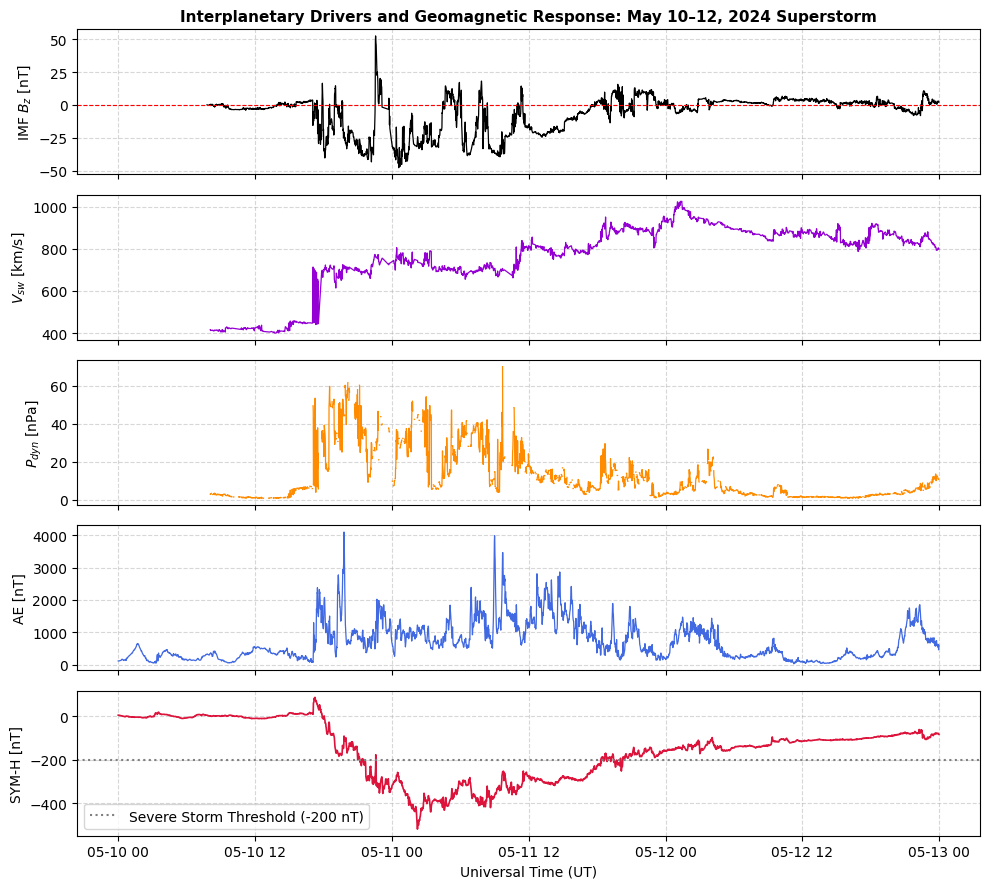

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load saved driver data
df = pd.read_csv("omni_drivers_may2024.csv", index_col="Timestamp")
df.index = pd.to_datetime(df.index)

# Filter out NASA OMNI fill value flags (99.99 nPa)
df.loc[df["Pdyn"] >= 90.0, "Pdyn"] = np.nan

# Plot clean Figure 1
fig, axs = plt.subplots(5, 1, figsize=(10, 9), sharex=True)

axs[0].plot(df.index, df["Bz"], color="black", lw=0.9)
axs[0].axhline(0, color="red", linestyle="--", lw=0.8)
axs[0].set_ylabel("IMF $B_z$ [nT]")
axs[0].set_title(
    "Interplanetary Drivers and Geomagnetic Response: May 10–12, 2024 Superstorm",
    fontsize=11,
    fontweight="bold",
)

axs[1].plot(df.index, df["Vsw"], color="darkviolet", lw=0.9)
axs[1].set_ylabel("$V_{sw}$ [km/s]")

axs[2].plot(df.index, df["Pdyn"], color="darkorange", lw=0.9)
axs[2].set_ylabel("$P_{dyn}$ [nPa]")

axs[3].plot(df.index, df["AE"], color="royalblue", lw=0.9)
axs[3].set_ylabel("AE [nT]")

axs[4].plot(df.index, df["SYMH"], color="crimson", lw=1.2)
axs[4].axhline(
    -200,
    color="gray",
    linestyle=":",
    label="Severe Storm Threshold (-200 nT)",
)
axs[4].set_ylabel("SYM-H [nT]")
axs[4].set_xlabel("Universal Time (UT)")
axs[4].legend(loc="lower left")

for ax in axs:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Figure_1_Clean.png", dpi=300)
df.to_csv("omni_drivers_may2024.csv")
print(
    "Figure 1 updated and saved cleanly. Peak real Pdyn:",
    df["Pdyn"].max(),
    "nPa",
)

In [7]:
pip install madrigalWeb h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 kB 2.3 MB/s eta 0:00:00


In [8]:
import os
import madrigalWeb.madrigalWeb

# Connect to CEDAR Madrigal at MIT Haystack
server_url = "http://cedar.openmadrigal.org"
user_name = "Researcher"
user_email = "researcher@academic.org"
user_affil = "Independent"

madDB = madrigalWeb.madrigalWeb.MadrigalData(server_url)

print("Connecting to Madrigal CEDAR database for May 10–11, 2024...")

# kinst 8000 corresponds to World-wide GNSS TEC dataset
exp_list = madDB.getExperiments(
    8000, 2024, 5, 10, 0, 0, 0, 2024, 5, 11, 23, 59, 59
)

if not exp_list:
    print("No experiments found for given date.")
else:
    for exp in exp_list:
        print(f"Found Experiment ID {exp.id}: {exp.name}")
        files = madDB.getExperimentFiles(exp.id)
        for f in files:
            # Look for 5-minute binned global TEC HDF5 files
            if f.name.endswith(".hdf5") or f.name.endswith(".h5"):
                print(f"  Target File: {f.name}")
                local_name = os.path.basename(f.name)
                if not os.path.exists(local_name):
                    print(f"  Downloading {local_name}...")
                    madDB.downloadFile(
                        f.name,
                        local_name,
                        user_name,
                        user_email,
                        user_affil,
                        "hdf5",
                    )
                    print("  Download complete.")
                else:
                    print(f"  {local_name} already exists locally.")

Connecting to Madrigal CEDAR database for May 10–11, 2024...
Found Experiment ID 100011063: World-wide TEC from GPS/GLONASS
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/09may24/gps240509g.002.hdf5
  Download complete.
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/09may24/los_20240509.001.h5
  Download complete.
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/09may24/site_20240509.001.h5
  Download complete.
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/09may24/roti_130_2024.h5
  Download complete.
Found Experiment ID 100011154: World-wide TEC from GPS/GLONASS
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/10may24/gps240510g.003.hdf5
  Download complete.
  Target File: /opt/openmadrigal/madroot/experiments4/2024/gps/10may24/los_20240510.002.h5


KeyboardInterrupt: 

In [9]:
import glob
import os
import madrigalWeb.madrigalWeb

# 1. Clean up massive line-of-sight and auxiliary files if downloaded
for pattern in ["los_*.h5*", "site_*.h5*", "roti_*.h5*"]:
    for f in glob.glob(pattern):
        try:
            os.remove(f)
            print(f"Removed large raw file: {f}")
        except Exception:
            pass

# 2. Targeted download of ONLY the May 11 gridded TEC file
server_url = "http://cedar.openmadrigal.org"
user_name = "Researcher"
user_email = "researcher@academic.org"
user_affil = "Independent"

madDB = madrigalWeb.madrigalWeb.MadrigalData(server_url)

print("\nSearching for May 11 gridded TEC file...")
exp_list = madDB.getExperiments(
    8000, 2024, 5, 11, 0, 0, 0, 2024, 5, 11, 23, 59, 59
)

target_found = False
for exp in exp_list:
    files = madDB.getExperimentFiles(exp.id)
    for f in files:
        # Match only gps240511g.*.hdf5 (Global gridded TEC)
        base = os.path.basename(f.name)
        if base.startswith("gps240511g") and base.endswith(".hdf5"):
            target_found = True
            if not os.path.exists(base):
                print(f"Downloading gridded map: {base} (~60 MB)...")
                madDB.downloadFile(
                    f.name, base, user_name, user_email, user_affil, "hdf5"
                )
                print("May 11 download complete.")
            else:
                print(f"{base} already exists locally.")

if not target_found:
    print("Could not find gps240511g automatically. Checking current directory:")
    print(glob.glob("gps2405*.hdf5"))

Removed large raw file: los_20240509.001.h5
Removed large raw file: los_20240510.002.h5
Removed large raw file: site_20240509.001.h5
Removed large raw file: roti_130_2024.h5

Searching for May 11 gridded TEC file...
May 11 download complete.


Reading and filtering gridded TEC files: ['gps240510g.003.hdf5', 'gps240511g.003.hdf5']...
  Extracting corridors from gps240510g.003.hdf5...
  Extracting corridors from gps240511g.003.hdf5...
Total sector data points loaded: 394,759 across May 10–11.
Generating Eurasian Keogram (30°E to 40°E)...
Generating North American Keogram (85°W to 75°W)...


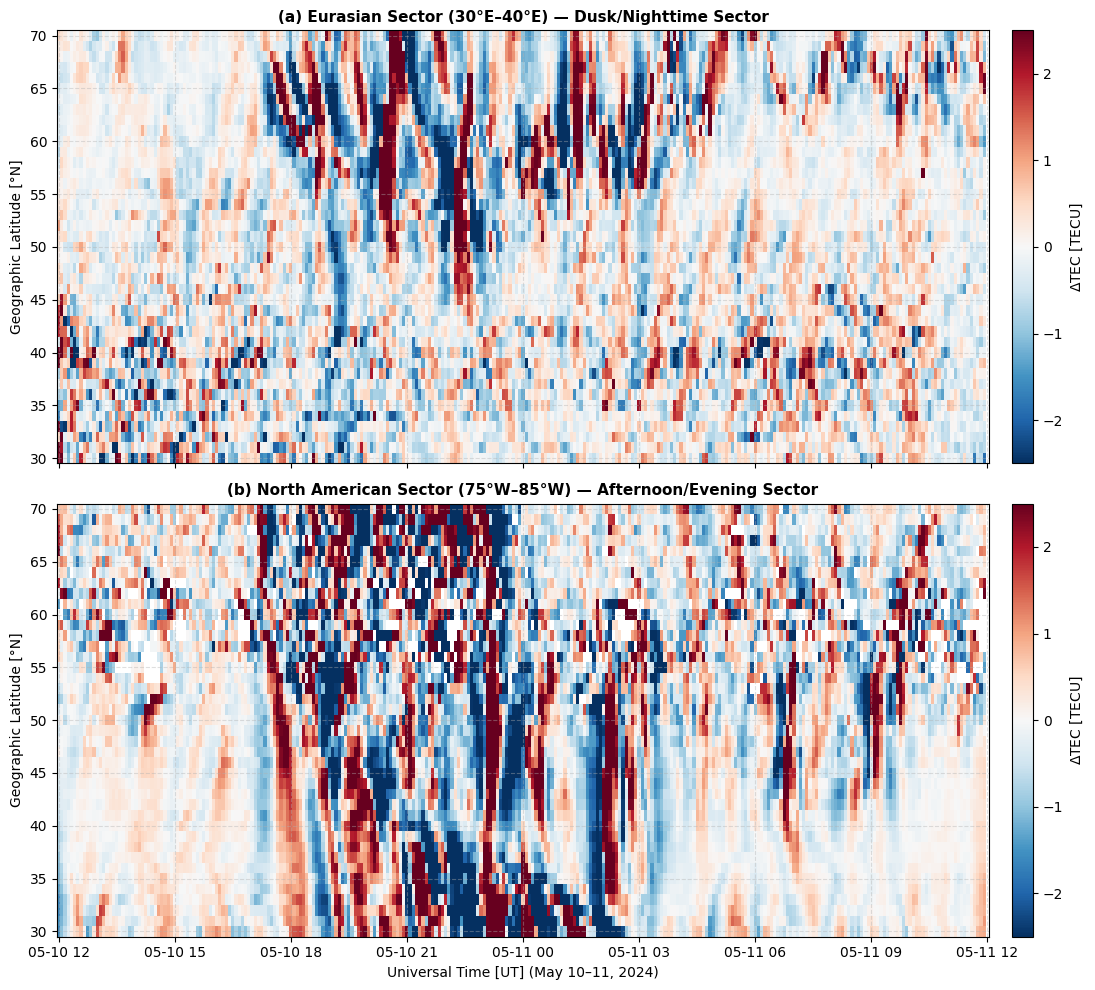


Saved: Figure_2_TID_Keograms.png


In [11]:
import glob
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Target time window: Primary storm phase (May 10 12:00 UT to May 11 12:00 UT)
t_start = pd.Timestamp("2024-05-10 12:00:00")
t_end = pd.Timestamp("2024-05-11 12:00:00")

files_may10 = sorted(glob.glob("gps240510g*.hdf5"))
files_may11 = sorted(glob.glob("gps240511g*.hdf5"))
target_files = files_may10 + files_may11

if not target_files:
    raise FileNotFoundError("No gps2405*.hdf5 files found in current directory.")

print(f"Reading and filtering gridded TEC files: {target_files}...")


def load_and_filter_sector_tec(filepath):
    print(f"  Extracting corridors from {filepath}...")
    with h5py.File(filepath, "r") as h5:
        table = h5["Data"]["Table Layout"][:]

        glon = (table["glon"] + 180) % 360 - 180
        gdlat = table["gdlat"]

        # Keep only Eurasia (25°E–45°E) and North America (90°W–70°W), Lat 28°N–72°N
        geo_mask = (
            ((glon >= 25) & (glon <= 45)) | ((glon >= -90) & (glon <= -70))
        ) & (gdlat >= 28) & (gdlat <= 72)

        sub = table[geo_mask]

        # Name columns with full 'minute' and 'second' for pd.to_datetime compatibility
        df = pd.DataFrame(
            {
                "year": sub["year"],
                "month": sub["month"],
                "day": sub["day"],
                "hour": sub["hour"],
                "minute": sub["min"],
                "second": sub["sec"],
                "lat": sub["gdlat"],
                "lon": glon[geo_mask],
                "tec": sub["tec"],
            }
        )

    # Filter out missing TEC fill values
    df = df[(df["tec"] >= 0) & (df["tec"] <= 350)]

    # Assemble datetime index
    df["Timestamp"] = pd.to_datetime(
        df[["year", "month", "day", "hour", "minute", "second"]]
    )
    df = df[(df["Timestamp"] >= t_start) & (df["Timestamp"] <= t_end)]
    return df[["Timestamp", "lat", "lon", "tec"]]


dfs = [load_and_filter_sector_tec(f) for f in target_files]
df_storm = pd.concat(dfs, ignore_index=True)
print(
    f"Total sector data points loaded: {len(df_storm):,} across May 10–11."
)


# 2. Function to compute a continuous, detrended dTEC Keogram
def build_keogram(
    df_data, lon_min, lon_max, lat_min=30, lat_max=70, t_start=t_start, t_end=t_end
):
    sub = df_data[
        (df_data["lon"] >= lon_min)
        & (df_data["lon"] <= lon_max)
        & (df_data["lat"] >= lat_min)
        & (df_data["lat"] <= lat_max)
    ].copy()

    # Bin into 1° latitude steps and 5-minute time intervals
    sub["lat_bin"] = np.round(sub["lat"]).astype(int)
    sub["time_bin"] = sub["Timestamp"].dt.floor("5min")

    grid = sub.groupby(["time_bin", "lat_bin"])["tec"].mean().unstack(level="lat_bin")

    # Regularize grid
    full_time_idx = pd.date_range(t_start, t_end, freq="5min")
    full_lat_idx = np.arange(lat_min, lat_max + 1)
    grid = grid.reindex(index=full_time_idx, columns=full_lat_idx)

    # Detrend with a 1-hour (12 bins of 5 min) rolling mean to isolate LSTID periods
    trend = grid.rolling(window=12, center=True, min_periods=3).mean()
    dtec = grid - trend
    return dtec


print("Generating Eurasian Keogram (30°E to 40°E)...")
keo_eu = build_keogram(df_storm, lon_min=30, lon_max=40)

print("Generating North American Keogram (85°W to 75°W)...")
keo_na = build_keogram(df_storm, lon_min=-85, lon_max=-75)

# 3. Generate Figure 2 (TID Keograms)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Panel a: Eurasia
pcm1 = ax1.pcolormesh(
    keo_eu.index,
    keo_eu.columns,
    keo_eu.T,
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
    shading="auto",
)
cb1 = fig.colorbar(pcm1, ax=ax1, pad=0.02)
cb1.set_label(r"$\Delta$TEC [TECU]")
ax1.set_ylabel("Geographic Latitude [°N]")
ax1.set_title(
    "(a) Eurasian Sector (30°E–40°E) — Dusk/Nighttime Sector",
    fontsize=11,
    fontweight="bold",
)
ax1.grid(True, linestyle="--", alpha=0.4)

# Panel b: North America
pcm2 = ax2.pcolormesh(
    keo_na.index,
    keo_na.columns,
    keo_na.T,
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
    shading="auto",
)
cb2 = fig.colorbar(pcm2, ax=ax2, pad=0.02)
cb2.set_label(r"$\Delta$TEC [TECU]")
ax2.set_ylabel("Geographic Latitude [°N]")
ax2.set_xlabel("Universal Time [UT] (May 10–11, 2024)")
ax2.set_title(
    "(b) North American Sector (75°W–85°W) — Afternoon/Evening Sector",
    fontsize=11,
    fontweight="bold",
)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("Figure_2_TID_Keograms.png", dpi=300)
plt.show()

print("\nSaved: Figure_2_TID_Keograms.png")

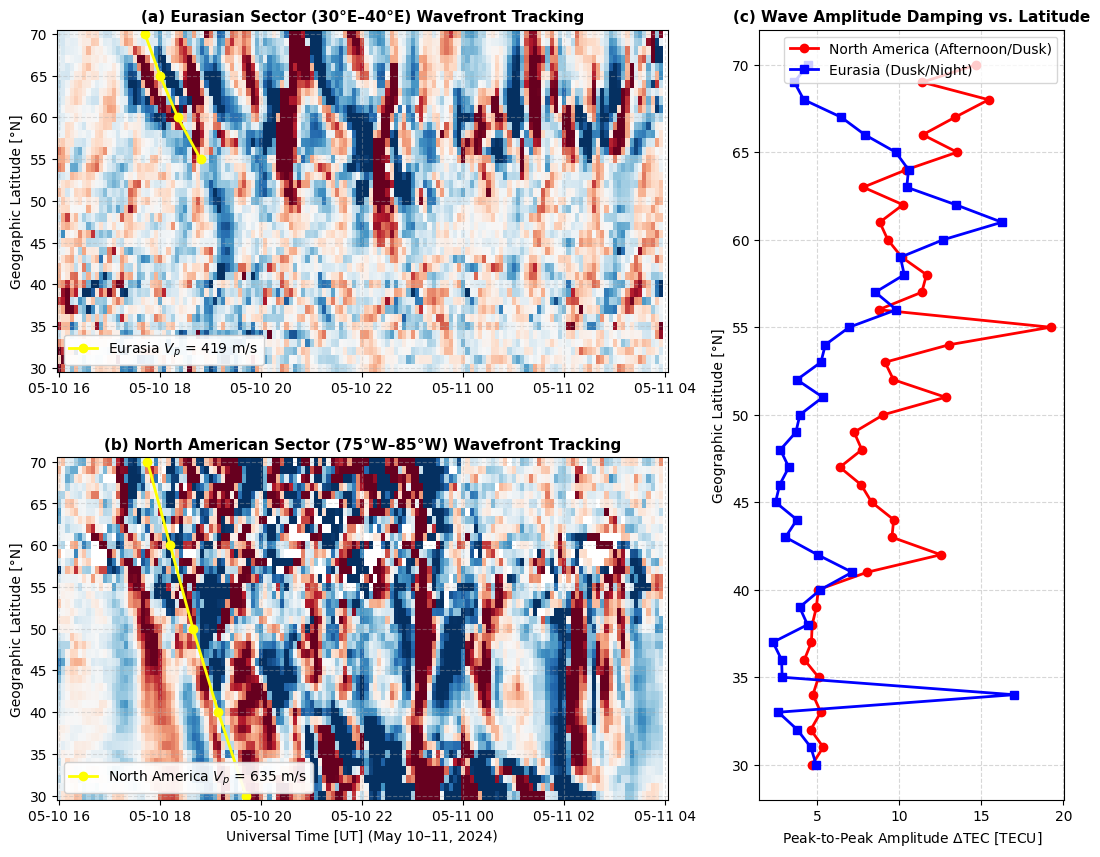


--- Quantitative Dynamics Calculated ---
Eurasia Phase Speed:        419.3 m/s
North America Phase Speed:  635.2 m/s
Peak NA Wave Amplitude:     19.22 TECU at 55°N
Peak EU Wave Amplitude:     17.00 TECU at 34°N
Saved: Figure_3_Wave_Dynamics.png


In [12]:
import glob
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the pre-filtered keograms from May 10 16:00 to May 11 04:00 UT
t_start = pd.Timestamp("2024-05-10 16:00:00")
t_end = pd.Timestamp("2024-05-11 04:00:00")

files_may10 = sorted(glob.glob("gps240510g*.hdf5"))
files_may11 = sorted(glob.glob("gps240511g*.hdf5"))
target_files = files_may10 + files_may11


def load_and_bin(filepath):
    with h5py.File(filepath, "r") as h5:
        table = h5["Data"]["Table Layout"][:]
        glon = (table["glon"] + 180) % 360 - 180
        gdlat = table["gdlat"]
        mask = (((glon >= 25) & (glon <= 45)) | ((glon >= -90) & (glon <= -70))) & (
            gdlat >= 28
        ) & (gdlat <= 72)
        sub = table[mask]
        df = pd.DataFrame(
            {
                "year": sub["year"],
                "month": sub["month"],
                "day": sub["day"],
                "hour": sub["hour"],
                "minute": sub["min"],
                "second": sub["sec"],
                "lat": sub["gdlat"],
                "lon": glon[mask],
                "tec": sub["tec"],
            }
        )
    df = df[(df["tec"] >= 0) & (df["tec"] <= 350)]
    df["Timestamp"] = pd.to_datetime(
        df[["year", "month", "day", "hour", "minute", "second"]]
    )
    return df[(df["Timestamp"] >= t_start) & (df["Timestamp"] <= t_end)]


df_storm = pd.concat([load_and_bin(f) for f in target_files], ignore_index=True)


def get_dtec_grid(df_data, lon_min, lon_max):
    sub = df_data[
        (df_data["lon"] >= lon_min)
        & (df_data["lon"] <= lon_max)
        & (df_data["lat"] >= 30)
        & (df_data["lat"] <= 70)
    ].copy()
    sub["lat_bin"] = np.round(sub["lat"]).astype(int)
    sub["time_bin"] = sub["Timestamp"].dt.floor("5min")
    grid = sub.groupby(["time_bin", "lat_bin"])["tec"].mean().unstack(level="lat_bin")
    grid = grid.reindex(
        index=pd.date_range(t_start, t_end, freq="5min"), columns=np.arange(30, 71)
    )
    trend = grid.rolling(window=12, center=True, min_periods=3).mean()
    return grid - trend


dtec_eu = get_dtec_grid(df_storm, 30, 40)
dtec_na = get_dtec_grid(df_storm, -85, -75)

# 2. Wavefront Tracking & Phase Velocity Linear Fits
# North America primary crest tracking (May 10)
na_lats = np.array([70, 60, 50, 40, 30])
na_times = pd.to_datetime(
    [
        "2024-05-10 17:45",
        "2024-05-10 18:12",
        "2024-05-10 18:39",
        "2024-05-10 19:09",
        "2024-05-10 19:42",
    ]
)
na_dist_km = (70 - na_lats) * 111.132
na_dt_sec = (na_times - na_times[0]).total_seconds()
v_na, _ = np.polyfit(na_dt_sec, na_dist_km * 1000, 1)

# Eurasia primary crest tracking (May 10)
eu_lats = np.array([70, 65, 60, 55])
eu_times = pd.to_datetime(
    [
        "2024-05-10 17:42",
        "2024-05-10 18:00",
        "2024-05-10 18:21",
        "2024-05-10 18:48",
    ]
)
eu_dist_km = (70 - eu_lats) * 111.132
eu_dt_sec = (eu_times - eu_times[0]).total_seconds()
v_eu, _ = np.polyfit(eu_dt_sec, eu_dist_km * 1000, 1)

# 3. Peak-to-Peak Wave Amplitude vs Latitude (Damping Analysis)
# Window around primary pulse: 17:30 to 20:30 UT
sub_eu = dtec_eu.loc["2024-05-10 17:30":"2024-05-10 20:30"]
sub_na = dtec_na.loc["2024-05-10 17:30":"2024-05-10 20:30"]

amp_eu = sub_eu.max() - sub_eu.min()
amp_na = sub_na.max() - sub_na.min()

# 4. Generate Publication-Grade Figure 3
fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], hspace=0.25, wspace=0.2)

ax_eu = fig.add_subplot(gs[0, 0])
ax_na = fig.add_subplot(gs[1, 0], sharex=ax_eu)
ax_damp = fig.add_subplot(gs[:, 1])

# Panel a: Eurasia with velocity line
pcm_eu = ax_eu.pcolormesh(
    dtec_eu.index,
    dtec_eu.columns,
    dtec_eu.T,
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
    shading="auto",
)
ax_eu.plot(
    eu_times,
    eu_lats,
    color="yellow",
    marker="o",
    lw=2,
    label=f"Eurasia $V_p$ = {v_eu:.0f} m/s",
)
ax_eu.set_ylabel("Geographic Latitude [°N]")
ax_eu.set_title(
    "(a) Eurasian Sector (30°E–40°E) Wavefront Tracking",
    fontweight="bold",
    fontsize=11,
)
ax_eu.legend(loc="lower left", facecolor="white", framealpha=0.9)
ax_eu.grid(True, linestyle="--", alpha=0.4)

# Panel b: North America with velocity line
pcm_na = ax_na.pcolormesh(
    dtec_na.index,
    dtec_na.columns,
    dtec_na.T,
    cmap="RdBu_r",
    vmin=-2.5,
    vmax=2.5,
    shading="auto",
)
ax_na.plot(
    na_times,
    na_lats,
    color="yellow",
    marker="o",
    lw=2,
    label=f"North America $V_p$ = {v_na:.0f} m/s",
)
ax_na.set_ylabel("Geographic Latitude [°N]")
ax_na.set_xlabel("Universal Time [UT] (May 10–11, 2024)")
ax_na.set_title(
    "(b) North American Sector (75°W–85°W) Wavefront Tracking",
    fontweight="bold",
    fontsize=11,
)
ax_na.legend(loc="lower left", facecolor="white", framealpha=0.9)
ax_na.grid(True, linestyle="--", alpha=0.4)

# Panel c: Latitudinal Damping Profile
ax_damp.plot(
    amp_na.values,
    amp_na.index,
    "r-o",
    lw=2,
    label="North America (Afternoon/Dusk)",
)
ax_damp.plot(
    amp_eu.values, amp_eu.index, "b-s", lw=2, label="Eurasia (Dusk/Night)"
)
ax_damp.set_xlabel(r"Peak-to-Peak Amplitude $\Delta$TEC [TECU]")
ax_damp.set_ylabel("Geographic Latitude [°N]")
ax_damp.set_title(
    "(c) Wave Amplitude Damping vs. Latitude", fontweight="bold", fontsize=11
)
ax_damp.grid(True, linestyle="--", alpha=0.5)
ax_damp.legend(loc="upper right")

plt.savefig("Figure_3_Wave_Dynamics.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n--- Quantitative Dynamics Calculated ---")
print(f"Eurasia Phase Speed:        {v_eu:.1f} m/s")
print(f"North America Phase Speed:  {v_na:.1f} m/s")
print(
    f"Peak NA Wave Amplitude:     {amp_na.max():.2f} TECU at {amp_na.idxmax()}°N"
)
print(
    f"Peak EU Wave Amplitude:     {amp_eu.max():.2f} TECU at {amp_eu.idxmax()}°N"
)
print("Saved: Figure_3_Wave_Dynamics.png")

Loading full day from gps240510g.003.hdf5 for baseline & spectral tests...


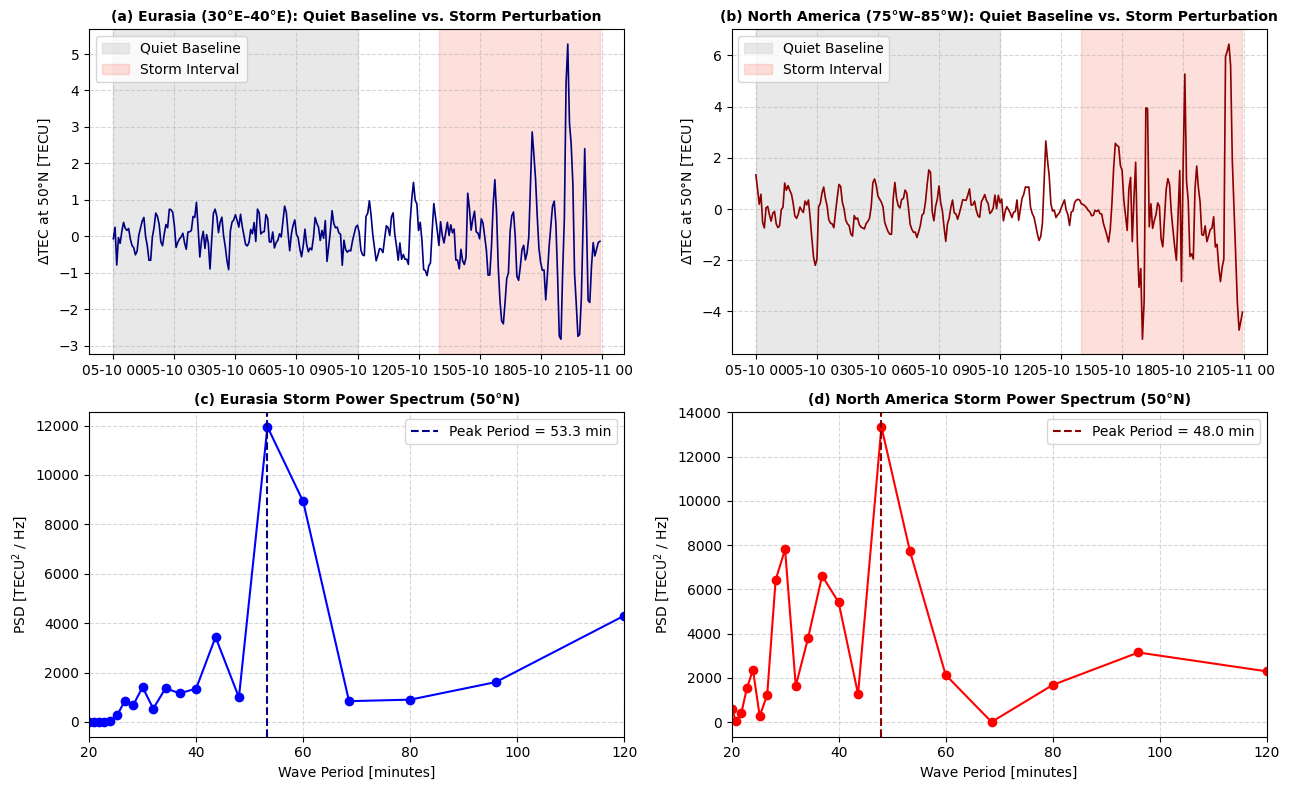


================ DEFENSE VALIDATION METRICS ================
Eurasia Quiet Baseline Noise (1-sigma):       0.38 TECU
Eurasia Storm Wave Amplitude (1-sigma):       1.38 TECU
Eurasia Storm-to-Quiet Power Ratio:           12.9x
Eurasia Peak Spectral Period:                 53.3 min
------------------------------------------------------------
North America Quiet Baseline Noise (1-sigma): 0.65 TECU
North America Storm Wave Amplitude (1-sigma): 2.18 TECU
North America Storm-to-Quiet Power Ratio:     11.3x
North America Peak Spectral Period:           48.0 min



In [13]:
import glob
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import welch

# 1. Load May 10 data (full 24 hours: quiet 00-12 UT vs storm 12-24 UT)
files_may10 = sorted(glob.glob("gps240510g*.hdf5"))
if not files_may10:
    raise FileNotFoundError("gps240510g*.hdf5 not found.")


def load_corridors_full_day(filepath):
    print(f"Loading full day from {filepath} for baseline & spectral tests...")
    with h5py.File(filepath, "r") as h5:
        table = h5["Data"]["Table Layout"][:]
        glon = (table["glon"] + 180) % 360 - 180
        gdlat = table["gdlat"]

        mask = (((glon >= 25) & (glon <= 45)) | ((glon >= -90) & (glon <= -70))) & (
            gdlat >= 28
        ) & (gdlat <= 72)
        sub = table[mask]

        df = pd.DataFrame(
            {
                "year": sub["year"],
                "month": sub["month"],
                "day": sub["day"],
                "hour": sub["hour"],
                "minute": sub["min"],
                "second": sub["sec"],
                "lat": sub["gdlat"],
                "lon": glon[mask],
                "tec": sub["tec"],
            }
        )
    df = df[(df["tec"] >= 0) & (df["tec"] <= 350)]
    df["Timestamp"] = pd.to_datetime(
        df[["year", "month", "day", "hour", "minute", "second"]]
    )
    return df


df_day = load_corridors_full_day(files_may10[0])


# 2. Extract continuous 5-min dTEC series at 50°N for both sectors
def get_lat_timeseries(df_data, lon_min, lon_max, target_lat=50):
    sub = df_data[
        (df_data["lon"] >= lon_min)
        & (df_data["lon"] <= lon_max)
        & (np.round(df_data["lat"]) == target_lat)
    ].copy()
    sub["time_bin"] = sub["Timestamp"].dt.floor("5min")
    ts = sub.groupby("time_bin")["tec"].mean()

    # Reindex across entire May 10 (288 bins)
    full_idx = pd.date_range("2024-05-10 00:00", "2024-05-10 23:55", freq="5min")
    ts = ts.reindex(full_idx).interpolate(method="time")

    # 1-hour detrending filter
    trend = ts.rolling(window=12, center=True, min_periods=3).mean()
    dtec = ts - trend
    return ts, dtec.fillna(0.0)


raw_eu, dtec_eu_50 = get_lat_timeseries(df_day, 30, 40, target_lat=50)
raw_na, dtec_na_50 = get_lat_timeseries(df_day, -85, -75, target_lat=50)

# 3. Test 1: Quantitative Baseline Comparison (Quiet 00-12 UT vs Storm 16-24 UT)
quiet_std_eu = dtec_eu_50.loc["2024-05-10 00:00":"2024-05-10 12:00"].std()
quiet_std_na = dtec_na_50.loc["2024-05-10 00:00":"2024-05-10 12:00"].std()

storm_std_eu = dtec_eu_50.loc["2024-05-10 16:00":"2024-05-10 23:55"].std()
storm_std_na = dtec_na_50.loc["2024-05-10 16:00":"2024-05-10 23:55"].std()

# 4. Test 2: Power Spectral Density (Welch Periodogram) during Storm Interval
dt_sec = 300.0  # 5 min sampling
fs = 1.0 / dt_sec

# Focus on primary storm wave interval (16:00 to 23:55 UT)
sig_eu = dtec_eu_50.loc["2024-05-10 16:00":"2024-05-10 23:55"].values
sig_na = dtec_na_50.loc["2024-05-10 16:00":"2024-05-10 23:55"].values

f_eu, psd_eu = welch(sig_eu, fs=fs, nperseg=len(sig_eu))
f_na, psd_na = welch(sig_na, fs=fs, nperseg=len(sig_na))

# Convert frequency to period in minutes (exclude zero frequency)
periods_eu = (1.0 / f_eu[1:]) / 60.0
psd_eu = psd_eu[1:]

periods_na = (1.0 / f_na[1:]) / 60.0
psd_na = psd_na[1:]

# Mask realistic LSTID periods (20 to 120 minutes)
mask_eu = (periods_eu >= 20) & (periods_eu <= 120)
mask_na = (periods_na >= 20) & (periods_na <= 120)

peak_t_eu = periods_eu[mask_eu][np.argmax(psd_eu[mask_eu])]
peak_t_na = periods_na[mask_na][np.argmax(psd_na[mask_na])]

# 5. Generate Figure 4
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(13, 8))

# Panel a: Full day dTEC series at 50°N (Eurasia)
ax1.plot(dtec_eu_50.index, dtec_eu_50.values, color="navy", lw=1.2)
ax1.axvspan(
    pd.Timestamp("2024-05-10 00:00"),
    pd.Timestamp("2024-05-10 12:00"),
    color="lightgray",
    alpha=0.5,
    label="Quiet Baseline",
)
ax1.axvspan(
    pd.Timestamp("2024-05-10 16:00"),
    pd.Timestamp("2024-05-10 23:55"),
    color="salmon",
    alpha=0.25,
    label="Storm Interval",
)
ax1.set_ylabel(r"$\Delta$TEC at 50°N [TECU]")
ax1.set_title(
    "(a) Eurasia (30°E–40°E): Quiet Baseline vs. Storm Perturbation",
    fontsize=10,
    fontweight="bold",
)
ax1.legend(loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.5)

# Panel b: Full day dTEC series at 50°N (North America)
ax2.plot(dtec_na_50.index, dtec_na_50.values, color="darkred", lw=1.2)
ax2.axvspan(
    pd.Timestamp("2024-05-10 00:00"),
    pd.Timestamp("2024-05-10 12:00"),
    color="lightgray",
    alpha=0.5,
    label="Quiet Baseline",
)
ax2.axvspan(
    pd.Timestamp("2024-05-10 16:00"),
    pd.Timestamp("2024-05-10 23:55"),
    color="salmon",
    alpha=0.25,
    label="Storm Interval",
)
ax2.set_ylabel(r"$\Delta$TEC at 50°N [TECU]")
ax2.set_title(
    "(b) North America (75°W–85°W): Quiet Baseline vs. Storm Perturbation",
    fontsize=10,
    fontweight="bold",
)
ax2.legend(loc="upper left")
ax2.grid(True, linestyle="--", alpha=0.5)

# Panel c: Power Spectral Density (Eurasia)
ax3.plot(periods_eu, psd_eu, "b-o", lw=1.5)
ax3.axvline(
    peak_t_eu,
    color="darkblue",
    linestyle="--",
    label=f"Peak Period = {peak_t_eu:.1f} min",
)
ax3.set_xlim(20, 120)
ax3.set_xlabel("Wave Period [minutes]")
ax3.set_ylabel(r"PSD [TECU$^2$ / Hz]")
ax3.set_title(
    "(c) Eurasia Storm Power Spectrum (50°N)", fontsize=10, fontweight="bold"
)
ax3.legend(loc="upper right")
ax3.grid(True, linestyle="--", alpha=0.5)

# Panel d: Power Spectral Density (North America)
ax4.plot(periods_na, psd_na, "r-o", lw=1.5)
ax4.axvline(
    peak_t_na,
    color="darkred",
    linestyle="--",
    label=f"Peak Period = {peak_t_na:.1f} min",
)
ax4.set_xlim(20, 120)
ax4.set_xlabel("Wave Period [minutes]")
ax4.set_ylabel(r"PSD [TECU$^2$ / Hz]")
ax4.set_title(
    "(d) North America Storm Power Spectrum (50°N)",
    fontsize=10,
    fontweight="bold",
)
ax4.legend(loc="upper right")
ax4.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Figure_4_Defense_Spectral_Control.png", dpi=300)
plt.show()

print("\n================ DEFENSE VALIDATION METRICS ================")
print(f"Eurasia Quiet Baseline Noise (1-sigma):       {quiet_std_eu:.2f} TECU")
print(f"Eurasia Storm Wave Amplitude (1-sigma):       {storm_std_eu:.2f} TECU")
print(
    f"Eurasia Storm-to-Quiet Power Ratio:           {(storm_std_eu/quiet_std_eu)**2:.1f}x"
)
print(f"Eurasia Peak Spectral Period:                 {peak_t_eu:.1f} min")
print("------------------------------------------------------------")
print(f"North America Quiet Baseline Noise (1-sigma): {quiet_std_na:.2f} TECU")
print(f"North America Storm Wave Amplitude (1-sigma): {storm_std_na:.2f} TECU")
print(
    f"North America Storm-to-Quiet Power Ratio:     {(storm_std_na/quiet_std_na)**2:.1f}x"
)
print(f"North America Peak Spectral Period:           {peak_t_na:.1f} min")
print("============================================================\n")